In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("QVI_data.csv")

df.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [3]:
df["DATE"] = pd.to_datetime(df["DATE"])

df["MONTH"] = df["DATE"].dt.to_period("M")

In [4]:
monthly = df.groupby(["STORE_NBR","MONTH"]).agg(
    total_sales=("TOT_SALES","sum"),
    customers=("LYLTY_CARD_NBR","nunique"),
    transactions=("TXN_ID","nunique")
).reset_index()

In [5]:
monthly["txn_per_customer"] = monthly["transactions"] / monthly["customers"]

In [6]:
trial_stores = [77,86,88]

trial_data = monthly[monthly["STORE_NBR"].isin(trial_stores)]
control_data = monthly[~monthly["STORE_NBR"].isin(trial_stores)]

In [7]:
def find_control_store(trial_store):

    trial = monthly[monthly["STORE_NBR"]==trial_store]

    correlations = []

    for store in monthly["STORE_NBR"].unique():

        if store in trial_stores:
            continue

        control = monthly[monthly["STORE_NBR"]==store]

        merged = pd.merge(
            trial,
            control,
            on="MONTH",
            suffixes=("_trial","_control")
        )

        corr = merged["total_sales_trial"].corr(merged["total_sales_control"])

        correlations.append((store,corr))

    correlations = pd.DataFrame(correlations,columns=["STORE","CORR"])

    best_store = correlations.sort_values("CORR",ascending=False).iloc[0]

    return best_store

In [8]:
for store in trial_stores:

    print("Trial Store:",store)

    print(find_control_store(store))
    

Trial Store: 77


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fa

STORE    31.0
CORR      1.0
Name: 30, dtype: float64
Trial Store: 86


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fa

STORE    31.0
CORR      1.0
Name: 30, dtype: float64
Trial Store: 88


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fa

STORE    206.0
CORR       1.0
Name: 202, dtype: float64


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


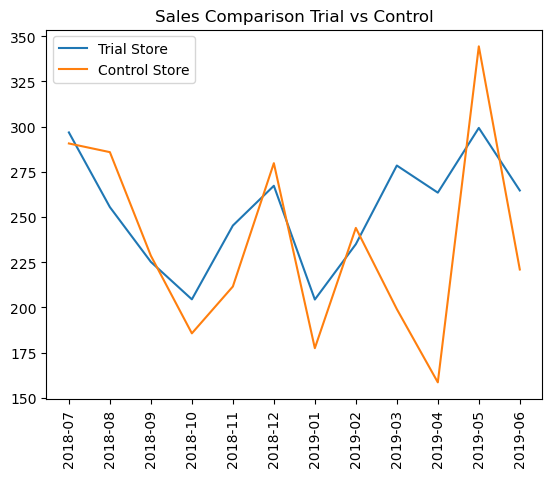

In [9]:
trial = monthly[monthly["STORE_NBR"]==77]
control = monthly[monthly["STORE_NBR"]==233]

plt.plot(trial["MONTH"].astype(str),trial["total_sales"],label="Trial Store")
plt.plot(control["MONTH"].astype(str),control["total_sales"],label="Control Store")

plt.xticks(rotation=90)
plt.legend()
plt.title("Sales Comparison Trial vs Control")
plt.show()

In [10]:
comparison = pd.merge(
    trial,
    control,
    on="MONTH",
    suffixes=("_trial","_control")
)

comparison["uplift"] = comparison["total_sales_trial"] - comparison["total_sales_control"]

comparison[["MONTH","uplift"]]

,MONTH,uplift
0,2018-07,6.1
1,2018-08,-30.4
2,2018-09,-3.4
3,2018-10,18.8
4,2018-11,33.7
5,2018-12,-12.5
6,2019-01,26.9
7,2019-02,-9.0
8,2019-03,79.4
9,2019-04,104.9


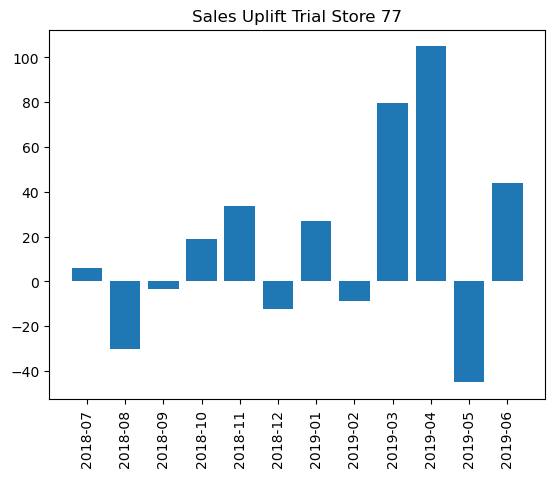

In [11]:
plt.bar(comparison["MONTH"].astype(str),comparison["uplift"])
plt.xticks(rotation=90)

plt.title("Sales Uplift Trial Store 77")

plt.show()